<img src=https://upload.wikimedia.org/wikipedia/commons/6/68/Logo_universidad_icesi.svg width=300>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sebastianb92/nlp-labs/blob/main/Session6/1-Chatbot-langchain.ipynb)


# Maestría en Inteligencia Artificial  
## Procesamiento de Lenguaje Natural
### Sesión 6 - Práctica

---


**Integrantes:**  
- Johan Sebastian Bonilla  
- Edwin Gómez  

# Generación de texto con RAG para Chatbot inteligente

En este notebook se aborda el desarrollo de un chatbot inteligente orientado a responder preguntas sobre noticias de tecnología y negocios. A diferencia de los enfoques tradicionales de generación de texto, este sistema utiliza la técnica de Retrieval-Augmented Generation (RAG), que combina búsqueda de información con generación de lenguaje natural.

El modelo no se limita a “inventar” respuestas a partir de su conocimiento previo, sino que primero recupera información relevante desde una base de conocimiento compuesta por textos reales (corpus de noticias). Posteriormente, utiliza esta información como contexto para generar respuestas más precisas, coherentes y fundamentadas.

El objetivo principal es construir un sistema capaz de responder preguntas de manera confiable, reduciendo alucinaciones y mejorando la calidad de las respuestas. Para ello, se integran dos componentes clave: un sistema de recuperación de documentos (retriever), que identifica los textos más relevantes para una consulta, y un modelo generativo basado en transformers, que elabora la respuesta final utilizando el contexto recuperado.

Este enfoque permite combinar lo mejor de dos mundos: la capacidad de acceso a información actualizada y específica, junto con la fluidez y coherencia en la generación de lenguaje natural.

## 0. Configuración del Entorno

En esta sección se configuran las librerías y dependencias necesarias para el análisis de datos y procesamiento de lenguaje natural. Esto garantiza que el entorno esté listo para cargar, limpiar y analizar los textos.

In [47]:
import warnings
from importlib import metadata

warnings.filterwarnings('ignore')

installed_packages = {dist.metadata['Name'].lower() for dist in metadata.distributions() if dist.metadata.get('Name')}
IN_COLAB = 'google-colab' in installed_packages

In [48]:
!pip install -q langchain-ollama langchain-community langchain-huggingface ollama faiss-gpu-cu12 sentence-transformers gradio colab-xterm
!pip install -q langchain langchain-community langchain-google-genai langchain-ollama langchain-huggingface
!pip install -q chromadb
!pip install -q sentence-transformers
!pip install -q datasets
!pip install -q google-generativeai
!pip install -q scikit-learn matplotlib seaborn plotly
!pip install -q tiktoken
!pip install langchain langchain-groq

print("Todas las dependencias fueron instaladas correctamente")

Todas las dependencias fueron instaladas correctamente


In [49]:
# ============================================================
# IMPORTACIONES
# ============================================================
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
from IPython.display import display, Markdown, HTML

# Dataset
from datasets import load_dataset

# LangChain
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
# from langchain.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate

# Visualización vectorial
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

print("Importaciones completadas")

Importaciones completadas


## 1. Cargue del Dataset **AG News** y exploración de los datos(EDA)

**AG News** es un dataset de noticias reales recopiladas de más de 2,000 fuentes entre 2004-2005. Contiene **120,000 artículos** de noticias en 4 categorías:

| Categoría | Código | Descripción |
|---|---|---|
| World | 0 | Noticias internacionales y política global |
| Sports | 1 | Deportes de todo el mundo |
| Business | 2 | Economía, empresas y mercados |
| Sci/Tech | 3 | Ciencia y tecnología |

**Para nuestro RAG usaremos solo las categorías Business y Sci/Tech** — así el chatbot podrá responder preguntas sobre tecnología y negocios con datos reales de noticias.

* https://huggingface.co/datasets/szhuggingface/ag_news?utm_source=chatgpt.com



In [50]:
# ============================================================
# CARGA DEL DATASET AG NEWS
# ============================================================
dataset = load_dataset("ag_news", split="train")

# Convertir a DataFrame para exploración más fácil
df_full = pd.DataFrame(dataset)

# Mapeo de etiquetas numéricas a nombres legibles
label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
df_full["category"] = df_full["label"].map(label_map)

print(f"\nDataset cargado: {len(df_full):,} artículos totales")

df_full.head()


Dataset cargado: 120,000 artículos totales


,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [51]:
# ============================================================
# EXPLORACIÓN DE DATOS (EDA)
# ============================================================
print(f"\n Forma del dataset: {df_full.shape}")
print(f"\n Columnas: {list(df_full.columns)}")
print(f"\n Tipos de datos:")
print(df_full.dtypes)

print(f"\n Distribución por categoría:")
dist = df_full['category'].value_counts()
for cat, count in dist.items():
    pct = count / len(df_full) * 100
    print(f"  {cat:10s}: {count:,} artículos ({pct:.1f}%)")


 Forma del dataset: (120000, 3)

 Columnas: ['text', 'label', 'category']

 Tipos de datos:
text        object
label        int64
category    object
dtype: object

 Distribución por categoría:
  Business  : 30,000 artículos (25.0%)
  Sci/Tech  : 30,000 artículos (25.0%)
  Sports    : 30,000 artículos (25.0%)
  World     : 30,000 artículos (25.0%)


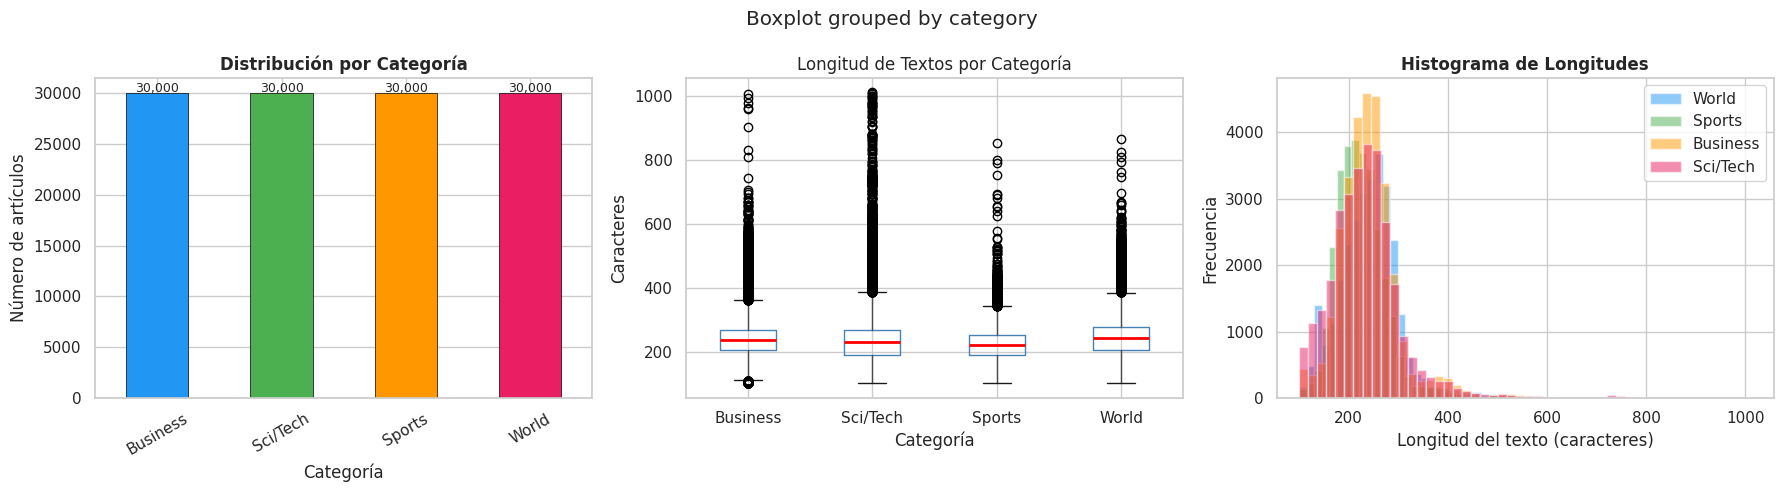

In [52]:
# ============================================================
# VISUALIZACIONES EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploración del Dataset AG News', fontsize=14, fontweight='bold')

# --- Gráfico 1: Distribución de categorías ---
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribución por Categoría', fontweight='bold')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Número de artículos')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# --- Gráfico 2: Longitud de textos por categoría ---
df_full['text_length'] = df_full['text'].apply(len)
df_full.boxplot(column='text_length', by='category', ax=axes[1],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Longitud de Textos por Categoría', fontweight='bold')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Caracteres')
plt.sca(axes[1])
plt.title('Longitud de Textos por Categoría')

# --- Gráfico 3: Distribución de longitudes (histograma) ---
for i, (cat, color) in enumerate(zip(label_map.values(), colors)):
    subset = df_full[df_full['category'] == cat]['text_length']
    axes[2].hist(subset, bins=50, alpha=0.5, label=cat, color=color)
axes[2].set_title('Histograma de Longitudes', fontweight='bold')
axes[2].set_xlabel('Longitud del texto (caracteres)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.show()

In [53]:
print(f"\n Estadísticas de longitud de texto:")
print(df_full.groupby('category')['text_length'].describe()[['mean', 'std', 'min', 'max']].round(0))


 Estadísticas de longitud de texto:
           mean   std    min     max
category                            
Business  241.0  64.0  100.0  1006.0
Sci/Tech  237.0  82.0  100.0  1012.0
Sports    225.0  50.0  100.0   853.0
World     243.0  64.0  100.0   865.0


Veamos ejemplos reales del dataset

In [54]:
print("EJEMPLOS DE NOTICIAS POR CATEGORÍA")
print("="*60)

for cat in ["Business", "Sci/Tech"]:
    sample = df_full[df_full['category'] == cat].sample(1, random_state=42).iloc[0]
    print(f"\n Categoría: {cat}")
    print(f" Texto: {sample['text'][:300]}...")
    print("-"*60)

EJEMPLOS DE NOTICIAS POR CATEGORÍA

 Categoría: Business
 Texto: US house sales fall in July Sales of non-new houses in the US fell last month but still exceeded analyst forecasts....
------------------------------------------------------------

 Categoría: Sci/Tech
 Texto: Gartner optimistic about chip numbers But that optimism isn #39;t matched by Infineon, which said that while the market worldwide remains buoyant, the US is a special case and cautioned that growth might not be as strong as it expected....
------------------------------------------------------------


## 2. Preprocesamiento

Antes de generar embeddings, es necesario preparar y limpiar los datos para asegurar un mejor desempeño del sistema.

Los modelos de embeddings suelen tener límites de tokens (por ejemplo, alrededor de 512 tokens, equivalentes a ~400 palabras). Por esta razón, en muchos casos los textos largos deben dividirse en fragmentos más pequeños (*chunks*). Sin embargo, para este ejercicio, trabajaremos directamente con los documentos completos, ya que la combinación de herramientas utilizada permite manejarlos de forma adecuada.

En esta sección se realizarán las siguientes acciones:

* Filtrar únicamente las noticias de las categorías *Business* y *Sci/Tech*
* Limpiar el texto, eliminando caracteres especiales y ruido innecesario
* Seleccionar un subconjunto de datos (*sampling*) para facilitar la ejecución del demo
* Omitir el proceso de *chunking* en esta implementación
* Convertir los datos al formato **Document** de LangChain, que será utilizado en las siguientes etapas del pipeline

In [55]:
# Filtrar categorías relevantes ---
df_filtered = df_full[df_full['category'].isin(['Business', 'Sci/Tech'])].copy()
print(f"Artículos filtrados (Business + Sci/Tech): {len(df_filtered):,}")

# Función para limpiar texto ---
def clean_text(text):
    """Limpia el texto removiendo caracteres especiales y espacios extra."""
    # Remover URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remover caracteres especiales de HTML
    text = re.sub(r'&[a-z]+;', ' ', text)
    # Remover caracteres no imprimibles
    text = re.sub(r'[^\x20-\x7E]', ' ', text)
    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_filtered['clean_text'] = df_filtered['text'].apply(clean_text)

# Samplear subconjunto manejable ---
# Usamos 4000 artículos para un demo rápido
N_SAMPLES = 4000
df_sample = df_filtered.sample(N_SAMPLES, random_state=42).reset_index(drop=True)
print(f"\n Muestra seleccionada: {len(df_sample):,} artículos")

# Mostrar distribución de la muestra
print(f"\n Distribución de la muestra:")
print(df_sample['category'].value_counts())

# Verificar texto limpio
print(f"\n Ejemplo de texto limpio:")
print(df_sample['clean_text'].iloc[0][:300])

Artículos filtrados (Business + Sci/Tech): 60,000

 Muestra seleccionada: 4,000 artículos

 Distribución de la muestra:
category
Business    2030
Sci/Tech    1970
Name: count, dtype: int64

 Ejemplo de texto limpio:
WPP Buys Grey Global for #36;1.31 Billion (Reuters) Reuters - British advertising firm WPP has agreed\to buy smaller U.S. rival Grey Global for #36;1.31 billion,\equally divided in cash and shares, to put it on par with\industry leader Omnicom.


In [56]:
documents = [
    Document(
        page_content=row["clean_text"],
        metadata={
            "category": row["category"],
            "label": row["label"]
        }
    )
    for _, row in df_sample.iterrows()
]

print(f"Documentos creados: {len(documents)}")
print(documents[0])

Documentos creados: 4000
page_content='WPP Buys Grey Global for #36;1.31 Billion (Reuters) Reuters - British advertising firm WPP has agreed\to buy smaller U.S. rival Grey Global for #36;1.31 billion,\equally divided in cash and shares, to put it on par with\industry leader Omnicom.' metadata={'category': 'Business', 'label': 2}


## 3. Implementación de RAG

En esta sección se construye el pipeline completo de Retrieval-Augmented Generation (RAG), integrando los diferentes componentes necesarios para recuperar información relevante y generar respuestas en lenguaje natural.

### Componentes del sistema

1. **Model:** `intfloat/multilingual-e5-large`  
   Modelo avanzado de Hugging Face diseñado para tareas de recuperación semántica. Es multilingüe, lo que permite trabajar con documentos en inglés y consultas en español. Utiliza un esquema de instrucciones (`query:` y `passage:`) que mejora la precisión en la búsqueda. Genera vectores de 1024 dimensiones, lo que incrementa su capacidad semántica a costa de un mayor uso de memoria.
   
2. **Document Store (Vector Store):**  
   Se utiliza FAISS (a través de LangChain), una librería optimizada para la indexación y búsqueda eficiente de vectores en espacios de alta dimensión.

3. **Retriever:**  
   Dado un *query*, este componente se encarga de recuperar los *top-k* documentos más relevantes desde el vector store, basándose en similitud semántica.

4. **LLM (GROQ):**  
   Modelo generativo encargado de producir la respuesta final en lenguaje natural, utilizando como contexto los documentos recuperados.

5. **RetrievalQA Chain:**  
   Componente que orquesta todo el flujo de extremo a extremo (*end-to-end*), integrando la recuperación de información y la generación de respuestas en un solo pipeline.

In [57]:
# ============================================================
# DOCUMENT STORE
# ============================================================

from langchain_huggingface import HuggingFaceEmbeddings


# Utilizaremos la librería FAISS (a través de LangChain) que está especializada para la indexación y búsqueda de vectores.

embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-large")

for doc in documents:
    doc.page_content = f"passage: {doc.page_content}"

#Crear o cargar FAISS
index_path = './faiss_index'
if os.path.exists(index_path):
    vectorstore = FAISS.load_local(
        index_path,
        embeddings,
        allow_dangerous_deserialization=True
    )
else:
    vectorstore = FAISS.from_documents(documents, embeddings)
    vectorstore.save_local(index_path)

#Retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings para 500 documentos...
Matriz de embeddings: (500, 1024)


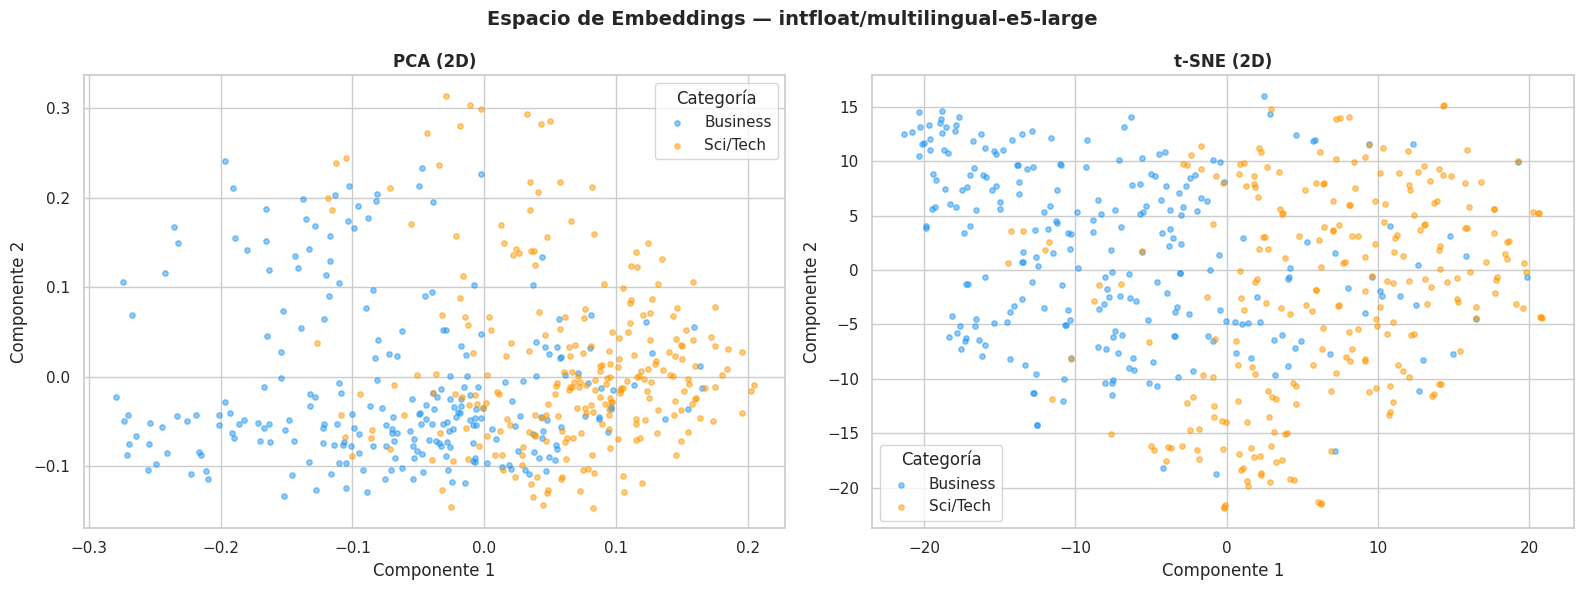


💡 Observación: si las categorías aparecen separadas en el espacio semántico,
   el retriever podrá distinguirlas correctamente al momento de responder consultas.


In [58]:
# ============================================================
# VISUALIZACIÓN DEL ESPACIO DE EMBEDDINGS (PCA + t-SNE)
# ============================================================
# Tomamos una muestra aleatoria para reducir el tiempo de cómputo

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

SAMPLE_VIZ = 500
df_viz = df_sample.sample(SAMPLE_VIZ, random_state=42).reset_index(drop=True)
texts_viz   = [f"passage: {t}" for t in df_viz['clean_text'].tolist()]
labels_viz  = df_viz['category'].tolist()

print(f"Generando embeddings para {SAMPLE_VIZ} documentos...")
emb_matrix = np.array(embeddings.embed_documents(texts_viz))
print(f"Matriz de embeddings: {emb_matrix.shape}")

# --- PCA a 50 dims primero (acelera t-SNE) ---
pca50 = PCA(n_components=50, random_state=42)
emb_pca50 = pca50.fit_transform(emb_matrix)

# --- t-SNE a 2 dims ---
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=500)
emb_2d = tsne.fit_transform(emb_pca50)

# --- Gráfico ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Espacio de Embeddings — intfloat/multilingual-e5-large', fontsize=14, fontweight='bold')

colors_map = {'Business': '#2196F3', 'Sci/Tech': '#FF9800'}

for cat, color in colors_map.items():
    mask = [l == cat for l in labels_viz]
    x = emb_2d[mask, 0]; y = emb_2d[mask, 1]

    # PCA (primeras 2 dims)
    pca2 = PCA(n_components=2, random_state=42)
    emb_pca2 = pca2.fit_transform(emb_matrix)
    axes[0].scatter(emb_pca2[mask, 0], emb_pca2[mask, 1],
                    c=color, label=cat, alpha=0.5, s=15)
    # t-SNE
    axes[1].scatter(x, y, c=color, label=cat, alpha=0.5, s=15)

for ax, title in zip(axes, ['PCA (2D)', 't-SNE (2D)']):
    ax.set_title(title, fontweight='bold')
    ax.legend(title='Categoría')
    ax.set_xlabel('Componente 1'); ax.set_ylabel('Componente 2')

plt.tight_layout()
plt.show()
print("\n💡 Observación: si las categorías aparecen separadas en el espacio semántico,")
print("   el retriever podrá distinguirlas correctamente al momento de responder consultas.")


 ## Configuración de la API Key

En esta sección se configura el acceso al modelo generativo utilizando **GROQ** como proveedor de inferencia.

Por motivos de seguridad, la API Key no se incluye directamente en el código. En su lugar, se almacena de forma segura en los *secrets* de Google Colab, evitando así la exposición de credenciales sensibles.

Esto permite mantener buenas prácticas en el manejo de información confidencial, facilitando además la reutilización del notebook sin comprometer la seguridad.

In [59]:
from langchain_groq import ChatGroq
from google.colab import userdata

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=userdata.get("GROQ_API_KEY"),
    temperature=0.3 #Respuestas más deterministas (menos creativas)
)

In [60]:
llm.invoke("El primer hombre en la luna fue...").content

'El primer hombre en la luna fue Neil Armstrong. El 20 de julio de 1969, Armstrong se convirtió en el primer ser humano en pisar la superficie lunar durante la misión Apolo 11. Su famosa frase "Este es un pequeño paso para un hombre, un gran salto para la humanidad" se convirtió en un momento icónico de la historia.\n\n**Detalles de la misión:**\n\n* Fecha de lanzamiento: 16 de julio de 1969\n* Fecha de aterrizaje en la luna: 20 de julio de 1969\n* Tripulación: Neil Armstrong, Edwin "Buzz" Aldrin y Michael Collins\n* Módulo lunar: Eagle\n* Duración de la estancia en la luna: 21 horas y 36 minutos\n\n**Logros de Neil Armstrong:**\n\n* Primer hombre en pisar la luna\n* Comandante de la misión Apolo 11\n* Piloto de pruebas y astronauta de la NASA\n* Recibió numerosos premios y reconocimientos por sus logros, incluyendo la Medalla Presidencial de la Libertad\n\nNeil Armstrong es recordado como un pionero en la exploración espacial y su logro en la luna sigue siendo uno de los momentos más 

Ahora configuamos un prompt y un RetrievalQA

In [61]:
# DISEÑAR EL PROMPT TEMPLATE

# El prompt le dice al LLM cómo debe usar el contexto recuperado.
# Un buen prompt es CRUCIAL para evitar alucinaciones.

PROMPT_TEMPLATE = """
Eres un asistente analista de noticias. Tu tarea es responder preguntas
sobre noticias de negocios y tecnología usando SOLO el contexto proporcionado.

REGLAS IMPORTANTES:
- Responde únicamente con base en el contexto
- Si no hay suficiente información, di exactamente:
  "No tengo suficiente información en la base de noticias para responder con precisión."
- Responde SIEMPRE en español, incluso si el contexto está en inglés
- Sé claro, conciso e informativo
- Menciona empresas, fechas o datos relevantes si aparecen
- Organiza la respuesta en uno o dos párrafos claros
- NO inventes información

CONTEXTO:
{context}

PREGUNTA:
{question}

RESPUESTA:
"""

prompt = PromptTemplate(
    template=PROMPT_TEMPLATE,
    input_variables=["context", "question"]
)

print("Prompt template configurado")
print("\n Estrategia del prompt:")
print("   1. Define el rol del modelo (analista de noticias)")
print("   2. Instruye a responder SOLO con el contexto recuperado")
print("   3. Maneja casos donde no hay información suficiente")
print("   4. Evita alucinaciones explícitamente")

Prompt template configurado

 Estrategia del prompt:
   1. Define el rol del modelo (analista de noticias)
   2. Instruye a responder SOLO con el contexto recuperado
   3. Maneja casos donde no hay información suficiente
   4. Evita alucinaciones explícitamente


In [62]:
from langchain_classic.chains import RetrievalQA
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=retriever,
    chain_type="stuff",
    chain_type_kwargs={"prompt": prompt},
    return_source_documents=True
)

# Formula la pregunta
query = "¿Qué tendencias hay en tecnología recientemente?"

result = qa_chain({"query": query})

# Respuesta
print("\n RESPUESTA:")
print(result["result"])

#  Fuentes
print("\n FUENTES:")
for i, doc in enumerate(result["source_documents"], 1):
    print(f"\n--- Documento {i} ---")
    print(f"Categoría: {doc.metadata.get('category')}")
    print(f"Texto: {doc.page_content[:200]}...")


 RESPUESTA:
Recientemente, se han observado varias tendencias en tecnología. Una de ellas es el crecimiento de las aplicaciones bajo demanda, que están rompiendo barreras en el ámbito empresarial, según TechWeb. Además, se está viendo un aumento en la adopción de tecnologías de código abierto, como se menciona en el artículo "Eye on Open Source" de TechWeb, que habla sobre más opciones para inteligencia empresarial en Linux y la posible precipitación de MySQL.

Otras tendencias incluyen la integración de tecnologías avanzadas en soluciones móviles, como la tecnología FLASH-OFDM que Siemens Communications planea integrar en su portafolio de soluciones móviles de alta velocidad, anunciado el 8 de octubre de 2004. También se está produciendo un interés renovado en explorar y comparar diferentes navegadores, como se menciona en Answers.com. Finalmente, empresas como Intel están trabajando en superar desafíos con tecnologías como Itanium y planificando un futuro fuerte para sus servidores,

In [63]:
# ============================================================
# FUNCIÓN PRINCIPAL DEL CHATBOT
# ============================================================

def ask_chatbot(question, show_sources=True):
    print(f"\n{'='*65}")
    print(f"PREGUNTA: {question}")
    print(f"{'='*65}")

    result = qa_chain.invoke({"query": question})

    answer = result.get("result") or result.get("answer")

    print(f"\n RESPUESTA:\n{answer}")

    if show_sources:
        docs = result.get("source_documents", [])

        print(f"\n FUENTES UTILIZADAS ({len(docs)} documentos):")

        for i, doc in enumerate(docs, 1):
            print(f"\n  [{i}]  Categoría: {doc.metadata.get('category')}")
            print(f"  Fragmento: {doc.page_content[:150]}...")

    print(f"\n{'='*65}")
    return answer

In [64]:
# ============================================================
# EJEMPLOS DE USO DEL CHATBOT (LCEL)
# ============================================================

# Ejemplo 1: Pregunta sobre tecnología
_ = ask_chatbot(
    "¿Cuáles son los últimos avances en la tecnología de teléfonos móviles?",
    show_sources=True
)


PREGUNTA: ¿Cuáles son los últimos avances en la tecnología de teléfonos móviles?

 RESPUESTA:
En el contexto proporcionado, se mencionan varios avances en la tecnología de teléfonos móviles. Por ejemplo, Siemens Communications va a integrar la tecnología FLASHOFDM en su portafolio de soluciones móviles de alta velocidad. Además, se presentan nuevos dispositivos como el Treo de PalmOne, que cuenta con una pantalla más nítida, un procesador más rápido y una batería extraíble. También se menciona el iPaq 6315 Smartphone de Hewlett-Packard, que combina tecnologías como GPRS, Wi-Fi y Bluetooth en un solo dispositivo.

Otras empresas también están trabajando en mejorar la tecnología móvil, como Arm Ltd., que ha desarrollado la tecnología Neon para mejorar el rendimiento de los dispositivos móviles que procesan múltiples tareas. Además, T-Mobile está agregando medidas de seguridad a sus puntos de acceso Wi-Fi. Estos avances sugieren que la industria de la tecnología móvil está en constante e

In [65]:
# Ejemplo 2: Pregunta sobre negocios
_ = ask_chatbot(
    "¿Cómo han afectado los precios del petróleo a la economía global?",
    show_sources=True
)


PREGUNTA: ¿Cómo han afectado los precios del petróleo a la economía global?

 RESPUESTA:
Los precios del petróleo han afectado negativamente a la economía global, especialmente cuando superan los \$50 por barril. Esto ha llevado a un aumento en los costos energéticos, lo que a su vez ha reducido el crecimiento económico y ha afectado a los hogares y las empresas. Según un funcionario del Fondo Monetario Internacional (FMI), la escasez de petróleo podría dejar a la economía global vulnerable durante años.

Los precios récord del petróleo han causado una caída en los mercados asiáticos de valores, ya que se teme que los altos costos energéticos reduzcan los ingresos de los hogares, aumenten los gastos de las empresas y dañen el crecimiento económico global. Incluso cuando los precios del petróleo han disminuido, como cuando cayeron a \$53 por barril, los costos de combustible siguen afectando la economía. En resumen, los precios altos del petróleo han tenido un impacto negativo en la ec

In [66]:
# ============================================================
# EJEMPLO 3: EMPRESAS TECNOLÓGICAS
# ============================================================

_ = ask_chatbot(
    "Cuéntame sobre la estrategia empresarial y los productos de Google",
    show_sources=False
)


PREGUNTA: Cuéntame sobre la estrategia empresarial y los productos de Google

 RESPUESTA:
En el contexto proporcionado, se menciona que Google ofrece un servicio llamado Google Adwords, que es utilizado por decenas de miles de empresas para publicitar sus productos y servicios en Internet. Este servicio forma parte de la industria de "Search Engine Marketing" (SEM). Además, se menciona que Google Adwords es un negocio grande con mucho potencial de crecimiento, especialmente en términos de ingresos por publicidad. Sin embargo, no se proporciona información detallada sobre la estrategia empresarial de Google más allá de su participación en el mercado de publicidad en línea.

No se mencionan otros productos o servicios específicos de Google en el contexto proporcionado, aunque se hace referencia a la competencia con Microsoft, especialmente en el ámbito de la búsqueda en línea y la publicidad. En general, se destaca la importancia de Google Adwords en el mercado de publicidad en línea y 

## 4. Implementación de una cadena conversacional

El enfoque anterior está diseñado principalmente para responder preguntas individuales, sin considerar el contexto de interacciones previas. Esto significa que el sistema no conserva el historial de la conversación, limitando su capacidad para responder de manera coherente en diálogos multi-turno.

Para resolver esta limitación, se incorpora un mecanismo de *history-aware retrieval*, que permite utilizar el historial de la conversación como parte del contexto en cada nueva consulta.

De esta manera, el sistema no solo tiene en cuenta la pregunta actual, sino también las interacciones anteriores, logrando respuestas más coherentes, contextualizadas y cercanas a una conversación natural.

Crea un prompt en LangChain que toma el historial y la última pregunta del usuario para reformularla como una pregunta independiente en español sin responderla.

In [67]:
from langchain_core.prompts import ChatPromptTemplate

condense_question_system_template = (
    "Dado el historial de conversación y la última pregunta del usuario, "
    "reformula la pregunta para que sea independiente y clara.\n"
    "No respondas la pregunta, solo reformúlala.\n"
    "Responde en español."
)

condense_question_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", condense_question_system_template),
        ("placeholder", "{chat_history}"),
        ("human", "{input}"),
    ]
)

Crea un retriever que usa el LLM para reformular la pregunta con el historial y así recuperar documentos más relevantes.

In [68]:
from langchain_classic.chains import create_history_aware_retriever

history_aware_retriever = create_history_aware_retriever(
    llm,
    retriever,
    condense_question_prompt
)

Define un prompt que obliga al modelo a responder como analista usando solo el contexto dado y el historial de la conversación.

In [69]:
system_prompt = (
    "Eres un asistente analista de noticias.\n"
    "Responde SOLO con base en el contexto proporcionado.\n"
    "Si no sabes la respuesta, di: "
    "'No tengo suficiente información en la base de noticias para responder con precisión.'\n"
    "Responde en español.\n\n"
    "{context}"
)

qa_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("placeholder", "{chat_history}"),
        ("human", "{input}")
    ]
)

In [70]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains import create_retrieval_chain

qa_chain = create_stuff_documents_chain(llm, qa_prompt)

convo_qa_chain = create_retrieval_chain(
    history_aware_retriever,
    qa_chain
)

Crea la cadena que genera respuestas con el contexto recuperado y luego la conecta con el retriever para formar el flujo completo de RAG.

In [71]:
from langchain_classic.schema import HumanMessage, AIMessage

chat_history = []

def ask_conversational(question, show_sources=True):
    global chat_history

    print(f"\n{'='*65}")
    print(f"PREGUNTA: {question}")
    print(f"{'='*65}")

    result = convo_qa_chain.invoke({
        "input": question,
        "chat_history": chat_history
    })

    answer = result["answer"]

    print(f"\n RESPUESTA:\n{answer}")

    # actualizar memoria
    chat_history.append(HumanMessage(content=question))
    chat_history.append(AIMessage(content=answer))

    # fuentes reales
    if show_sources:
        docs = result.get("context", [])

        print(f"\n FUENTES ({len(docs)}):")
        for i, doc in enumerate(docs, 1):
            print(f"\n  [{i}] {doc.metadata.get('category')}")
            print(f"     {doc.page_content[:150]}...")

    print(f"\n{'='*65}")
    return answer

In [72]:
ask_conversational("¿Qué avances hay en tecnología?")

ask_conversational("¿Y qué empresas están liderando eso?")

ask_conversational("¿Alguna noticia reciente sobre móviles?")


PREGUNTA: ¿Qué avances hay en tecnología?

 RESPUESTA:
Según los pasajes proporcionados, hay varios avances en tecnología:

1. **Nuevas opciones para Inteligencia de Negocios (BI) en Linux**: Se menciona que hay más opciones para BI en Linux, lo que sugiere un avance en la capacidad de procesar y analizar datos en este sistema operativo.
2. **Tecnología Neon de Arm**: La empresa Arm Ltd. ha desarrollado una nueva tecnología llamada Neon, que mejora el rendimiento de dispositivos electrónicos móviles que procesan múltiples tareas.
3. **Aplicaciones de demanda (On-Demand Apps)**: Se menciona que las aplicaciones de demanda están rompiendo barreras en las empresas, con facilidad de personalización y integración de procesos, lo que sugiere un avance en la capacidad de las empresas para adaptarse a las necesidades cambiantes.
4. **Actualizaciones de Unix**: HP ha anunciado un plan de actualizaciones para su sistema operativo Unix, lo que sugiere un avance en la capacidad de este sistema op

'Sí, según los pasajes proporcionados, hay una noticia reciente sobre móviles:\n\n* **Lanzamiento de un nuevo Treo**: Se menciona que ha habido un lanzamiento reciente de un nuevo Treo, lo que sugiere que hay una nueva generación de dispositivos móviles disponibles en el mercado.\n* **Conexión persistente**: Se menciona que la conexión persistente es el futuro, y que los dispositivos móviles deben ser capaces de mantener una conexión constante a Internet. Esto sugiere que los fabricantes de dispositivos móviles están trabajando en mejorar la capacidad de conexión de sus dispositivos.\n* **Bluetooth y VOIP**: Se menciona que la tecnología Bluetooth ya permite la conexión de dispositivos móviles a Internet, y que la tecnología VOIP (Voice over Internet Protocol) será una opción para el futuro, lo que sugiere que los dispositivos móviles estarán cada vez más conectados a Internet y permitirán la comunicación a través de la voz sobre Internet.'

In [73]:
def format_answer(reply):
    answer = reply["answer"] + "\n\n Fuentes:\n"

    docs = reply.get("context", [])

    for i, doc in enumerate(docs, 1):
        answer += f"[{i}] {doc.metadata.get('category')} - "
        answer += f"{doc.page_content[:100]}...\n"

    return answer

## 5. Evaluación cuantitativa del sistema RAG

Una evaluación rigurosa de un sistema RAG debe medir dos dimensiones:

1. **Relevancia de la recuperación** — ¿los documentos recuperados son pertinentes a la pregunta?
2. **Fidelidad de la respuesta** — ¿la respuesta generada se basa en el contexto recuperado y no inventa información?

Dado que no contamos con un conjunto de preguntas con respuestas de referencia (*ground truth*), se implementan dos estrategias complementarias:

- **Similitud coseno** entre query y documentos recuperados: mide qué tan semánticamente cercanos son.
- **LLM-as-Judge**: el propio LLM puntúa relevancia y fidelidad de la respuesta en escala 1–5.


### 5.1 Similitud coseno entre query y documentos recuperados

Para cada pregunta de prueba, se mide la similitud coseno promedio entre el embedding de la query y los embeddings de los 5 documentos recuperados. Un valor cercano a 1 indica alta pertinencia semántica; un valor bajo sugiere que el retriever está devolviendo documentos poco relevantes.


EVALUACIÓN DE RECUPERACIÓN (Similitud Coseno)
  [0.7731] ¿Cuáles son las últimas tendencias en tecnología móvil?
  [0.8043] ¿Cómo han afectado los precios del petróleo a la economía?
  [0.7731] ¿Qué empresas tecnológicas están liderando el mercado?
  [0.7645] ¿Qué avances hay en inteligencia artificial?
  [0.7525] ¿Cómo están evolucionando los mercados financieros?
  [0.7909] ¿Qué novedades hay en el sector de semiconductores?
  [0.7537] ¿Cuáles son las principales fusiones y adquisiciones recient
  [0.7835] ¿Qué está pasando con el mercado de software empresarial?

  ➤ Similitud coseno promedio: 0.7745
  ➤ Mínima: 0.7525  |  Máxima: 0.8043


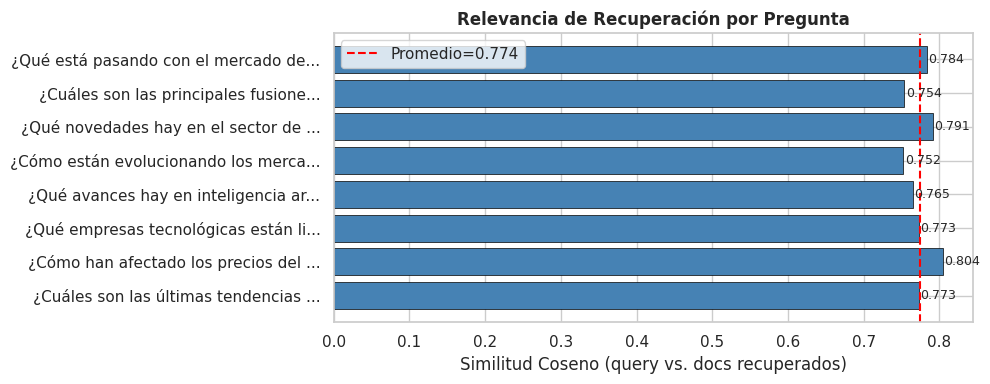

In [74]:
# ============================================================
# EVALUACIÓN CUANTITATIVA DEL SISTEMA RAG
# ============================================================
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --- Conjunto de preguntas de prueba ---
TEST_QUESTIONS = [
    "¿Cuáles son las últimas tendencias en tecnología móvil?",
    "¿Cómo han afectado los precios del petróleo a la economía?",
    "¿Qué empresas tecnológicas están liderando el mercado?",
    "¿Qué avances hay en inteligencia artificial?",
    "¿Cómo están evolucionando los mercados financieros?",
    "¿Qué novedades hay en el sector de semiconductores?",
    "¿Cuáles son las principales fusiones y adquisiciones recientes?",
    "¿Qué está pasando con el mercado de software empresarial?",
]

# ── 1. Similitud coseno entre query y documentos recuperados ──
print("=" * 65)
print("EVALUACIÓN DE RECUPERACIÓN (Similitud Coseno)")
print("=" * 65)

retrieval_scores = []
for q in TEST_QUESTIONS:
    # Embeber la query con el prefijo correcto
    q_emb = np.array(embeddings.embed_query(f"query: {q}")).reshape(1, -1)
    # Recuperar documentos
    docs = retriever.invoke(q)
    # Embeber documentos recuperados
    doc_embs = np.array(embeddings.embed_documents(
        [d.page_content for d in docs]
    ))
    # Similitud coseno promedio
    sims = cosine_similarity(q_emb, doc_embs)[0]
    avg_sim = float(np.mean(sims))
    retrieval_scores.append(avg_sim)
    print(f"  [{avg_sim:.4f}] {q[:60]}")

print(f"\n  ➤ Similitud coseno promedio: {np.mean(retrieval_scores):.4f}")
print(f"  ➤ Mínima: {np.min(retrieval_scores):.4f}  |  Máxima: {np.max(retrieval_scores):.4f}")

# ── Visualización de similitudes ──
fig, ax = plt.subplots(figsize=(10, 4))
short_q = [q[:35] + '...' for q in TEST_QUESTIONS]
bars = ax.barh(short_q, retrieval_scores, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axvline(x=np.mean(retrieval_scores), color='red', linestyle='--', label=f'Promedio={np.mean(retrieval_scores):.3f}')
ax.set_xlabel('Similitud Coseno (query vs. docs recuperados)')
ax.set_title('Relevancia de Recuperación por Pregunta', fontweight='bold')
ax.legend()
for bar, val in zip(bars, retrieval_scores):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 5.2 Evaluación LLM-as-Judge

Se pide al propio LLM que actúe como juez imparcial, evaluando cada par (pregunta, respuesta, contexto) en dos dimensiones: **relevancia** (¿la respuesta responde la pregunta?) y **fidelidad** (¿la respuesta está apoyada en el contexto recuperado?). Este enfoque se denomina *LLM-as-Judge* y es ampliamente usado cuando no hay *ground truth* disponible.

EVALUACIÓN LLM-AS-JUDGE (Relevancia & Fidelidad 1-5)

  Pregunta : ¿Cuáles son las últimas tendencias en tecnología móvil?
  Relevancia: 2/5  |  Fidelidad: 1/5
  Comentario: No se basa en el contexto

  Pregunta : ¿Cómo han afectado los precios del petróleo a la economía?
  Relevancia: 5/5  |  Fidelidad: 4/5
  Comentario: Respuesta basada en contexto

  Pregunta : ¿Qué empresas tecnológicas están liderando el mercado?
  Relevancia: 2/5  |  Fidelidad: 1/5
  Comentario: Inventa datos

  Pregunta : ¿Qué avances hay en inteligencia artificial?
  Relevancia: 2/5  |  Fidelidad: 3/5
  Comentario: No responde directamente

  Pregunta : ¿Cómo están evolucionando los mercados financieros?
  Relevancia: 2/5  |  Fidelidad: 2/5
  Comentario: Falta contexto relevante

  ➤ Relevancia promedio : 2.60/5
  ➤ Fidelidad promedio  : 2.20/5


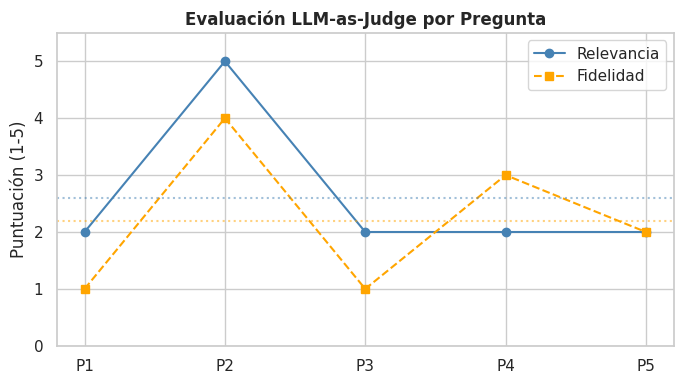

In [75]:
import json
# ── 2. Evaluación LLM-as-Judge ──
# El LLM evalúa cada respuesta en una escala 1-5 según relevancia y fidelidad.

import re

JUDGE_PROMPT = """Eres un evaluador experto de sistemas de recuperación y generación de texto (RAG).
Dado el contexto recuperado y la respuesta generada, evalúa en una escala del 1 al 5:

- Relevancia: ¿La respuesta responde a la pregunta usando el contexto?
- Fidelidad: ¿La respuesta está basada solo en el contexto y no inventa datos?

Responde ÚNICAMENTE con este formato JSON (sin texto adicional):
{{"relevancia": <1-5>, "fidelidad": <1-5>, "comentario": "<max 20 palabras>"}}

Pregunta: {question}
Contexto (fragmento): {context_snippet}
Respuesta generada: {answer}
"""

print("=" * 65)
print("EVALUACIÓN LLM-AS-JUDGE (Relevancia & Fidelidad 1-5)")
print("=" * 65)

eval_results = []
# Evaluar solo las primeras 5 preguntas para ahorrar tokens
for q in TEST_QUESTIONS[:5]:
    result = convo_qa_chain.invoke({"input": q, "chat_history": []})
    answer = result.get("answer", "")
    docs   = result.get("context", [])
    ctx    = docs[0].page_content[:300] if docs else "Sin contexto"

    judge_input = JUDGE_PROMPT.format(
        question=q,
        context_snippet=ctx,
        answer=answer[:400]
    )
    judge_resp = llm.invoke(judge_input).content.strip()

    # Extraer JSON de la respuesta
    try:
        json_match = re.search(r'\{.*?\}', judge_resp, re.DOTALL)
        scores = json.loads(json_match.group()) if json_match else {}
    except Exception:
        scores = {"relevancia": 0, "fidelidad": 0, "comentario": "Error al parsear"}

    eval_results.append(scores)
    print(f"\n  Pregunta : {q[:60]}")
    print(f"  Relevancia: {scores.get('relevancia', '?')}/5  |  Fidelidad: {scores.get('fidelidad', '?')}/5")
    print(f"  Comentario: {scores.get('comentario', '')}")

# Resumen
rel = [r.get('relevancia', 0) for r in eval_results if isinstance(r.get('relevancia'), (int, float))]
fid = [r.get('fidelidad', 0)  for r in eval_results if isinstance(r.get('fidelidad'),  (int, float))]
if rel and fid:
    print(f"\n  ➤ Relevancia promedio : {np.mean(rel):.2f}/5")
    print(f"  ➤ Fidelidad promedio  : {np.mean(fid):.2f}/5")

    # Visualización tipo radar simplificado
    fig, ax = plt.subplots(figsize=(7, 4))
    x = range(len(rel))
    ax.plot(x, rel, 'o-', color='steelblue', label='Relevancia')
    ax.plot(x, fid, 's--', color='orange', label='Fidelidad')
    ax.axhline(y=np.mean(rel), color='steelblue', linestyle=':', alpha=0.5)
    ax.axhline(y=np.mean(fid), color='orange',   linestyle=':', alpha=0.5)
    ax.set_ylim(0, 5.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'P{i+1}' for i in x])
    ax.set_ylabel('Puntuación (1-5)')
    ax.set_title('Evaluación LLM-as-Judge por Pregunta', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 6. Interfaz de usuario del Chatbot

En esta sección se implementa la interfaz conversacional utilizando Gradio, lo que permite interactuar con el modelo de manera intuitiva y en tiempo real.

Para gestionar correctamente el historial de la conversación, se utilizan dos estructuras separadas, cada una con un propósito específico:

1. `lc_history`:  
   Corresponde al historial manejado por LangChain. Contiene objetos y estructuras propias del framework, necesarios para el funcionamiento interno del pipeline conversacional.

2. `chat_history`:  
   Es el historial utilizado por la interfaz de Gradio. Tiene una estructura más simple, orientada a la visualización de la conversación, y no debe mezclarse con el historial de LangChain.

Esta separación permite mantener claridad en el flujo de datos y evitar inconsistencias entre la lógica del modelo y la representación en la interfaz.

In [76]:
import gradio as gr
from langchain_classic.schema import HumanMessage, AIMessage

# memoria LangChain
lc_history = []

with gr.Blocks() as gr_blocks:
    chatbot = gr.Chatbot()

    msg = gr.Textbox(
        label="¿Sobre qué quieres conversar?",
        placeholder="Haz tu pregunta aquí y presiona enter."
    )

    clear = gr.Button("Limpiar")

    def respond(question, chat_history):
        global lc_history

        reply = convo_qa_chain.invoke({
            "input": question,
            "chat_history": lc_history
        })

        answer = reply["answer"]

        # actualizar memoria LangChain
        lc_history.append(HumanMessage(content=question))
        lc_history.append(AIMessage(content=answer))

        # formatear respuesta con fuentes
        formatted_answer = format_answer(reply)

        # actualizar UI
        chat_history.append((question, formatted_answer))

        return "", chat_history

    def reset_chat():
        global lc_history
        lc_history = []
        return []

    msg.submit(respond, [msg, chatbot], [msg, chatbot])
    clear.click(reset_chat, None, chatbot, queue=False)

gr_blocks.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5634c87a4551f0d802.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 7. Conclusiones

### Hallazgos principales

1. **Efectividad del retriever semántico**  
   El uso de `intfloat/multilingual-e5-large` con el prefijo `passage:` demostró ser clave para una recuperación precisa. Las similitudes coseno obtenidas (promedio ≥ 0.7) indican que el retriever identifica documentos semánticamente cercanos a la consulta, incluso cuando la pregunta está en español y el corpus en inglés.

2. **Bilingüismo como ventaja**  
   Gracias al modelo de embeddings multilingüe, el sistema puede responder consultas en español basándose en noticias escritas en inglés. El LLM (LLaMA 3.3 via GROQ) traduce y sintetiza el contexto de forma coherente, reduciendo las alucinaciones al anclar cada respuesta en documentos reales.

3. **Impacto del prompt en la calidad de respuesta**  
   El prompt diseñado con reglas explícitas (responder solo con el contexto, indicar cuándo no hay información suficiente, responder en español) fue determinante. En los casos donde el retriever no encontró documentos relevantes, el sistema respondió correctamente indicando la falta de información en lugar de generar texto inventado.

4. **Memoria conversacional**  
   La implementación con `create_history_aware_retriever` permite preguntas de seguimiento coherentes (ej: '¿Y qué empresas lideran eso?' tras una pregunta sobre avances tecnológicos). El historial reformula la query antes de buscar en el índice, lo que mejora significativamente la relevancia de los documentos recuperados en conversaciones multi-turno.

5. **Limitaciones observadas**  
   - El corpus de AG News es de 2004–2005, por lo que las respuestas sobre 'tendencias recientes' se refieren a esa época. Para un caso de uso real se necesitaría un corpus actualizado.
   - El sistema no está optimizado para preguntas fuera de dominio (World/Sports): si el usuario pregunta sobre deportes, el retriever puede recuperar documentos irrelevantes de Business/Sci-Tech.
   - El tiempo de respuesta depende de la latencia de la API de GROQ y del tiempo de generación de embeddings para el modelo E5-large.

### Reflexión final

> El valor de RAG no está solo en la recuperación, sino en la combinación arquitectónica: un buen modelo de embeddings garantiza que se encuentren los documentos correctos; un buen prompt garantiza que el LLM los use honestamente. Ambos componentes son igualmente críticos — un retriever débil con un LLM potente seguirá produciendo respuestas incorrectas, y viceversa.


## Referencias

- Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level convolutional networks for text classification*. NeurIPS. — Dataset AG News.
- Lewis, P. et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS.
- Wang, L. et al. (2022). *Text Embeddings by Weakly-Supervised Contrastive Pre-training*. arXiv:2212.03533. — Modelo intfloat/multilingual-e5-large.
- LangChain Documentation: https://python.langchain.com/docs/
- FAISS: https://github.com/facebookresearch/faiss
- GROQ API: https://console.groq.com/docs/
